In [53]:
import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F
import numpy as np
from scipy.signal import welch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import sys
from pathlib import Path



PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
from evaluation import evaluate_autoencoder
from src.data.preprocessing import load_multiple_subjects
from src.data.H5_dataset import EEGH5Dataset
from src.models.embedder import cEmbedder
from src.models.recovery import cRecovery
from src.losses.losses import reconstruction_loss
from src.utils.config import (
    LATENT_DIM,
    LR_EMBEDDER,
    EPOCHS_EMBEDDER,
    WINDOW_SIZE,
    WINDOW_STRIDE,
    BATCH_SIZE,
    WANTED_CHANNELS,
    NUM_LAYERS_EMBEDDER,
    NUM_LAYERS_RECOVERY,
    NUM_CHANNELS
)
from src.utils.logging import get_logger


In [54]:
logger = get_logger("Evaluate autoencoder")

In [55]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [56]:
dataset = EEGH5Dataset("C:\\Users\\danie_13ucdo4\\OneDrive\\Desktop\\ITAM\\Tesis\\Prueba\\BestTimeGAN\\data\\processed\\test.h5")

In [57]:
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4,
)

logger.info(f"Dataset windows: {len(dataset)}")

2026-05-21 15:19:12 | INFO | Dataset windows: 6660


In [58]:
E = cEmbedder(
    x_dim=NUM_CHANNELS,
    h_dim=LATENT_DIM
).to(device)

R = cRecovery(
    h_dim=LATENT_DIM,
    x_dim=NUM_CHANNELS
).to(device)

logger.info("Embedder and Recovery initialized")

2026-05-21 15:19:12 | INFO | Embedder and Recovery initialized


In [59]:
E.load_state_dict(torch.load("c:\\Users\\danie_13ucdo4\\OneDrive\\Desktop\\ITAM\\Tesis\\Prueba\\BestTimeGAN\\checkpoints\\embedder_12.0.pt", weights_only=True))
R.load_state_dict(torch.load("c:\\Users\\danie_13ucdo4\\OneDrive\\Desktop\\ITAM\\Tesis\\Prueba\\BestTimeGAN\\checkpoints\\recovery_12.0.pt", weights_only=True))

<All keys matched successfully>

In [60]:
evaluate_autoencoder(E, R, dataloader)

{'distance_corr': 0.3067334070801735,
 'stress': 0.38448514640331266,
 'knn_overlap': 0.17,
 'psd_error': 0.6307963639497757,
 'acf_error': 0.0020062364405021072}

In [61]:
@torch.no_grad()
def evaluate_reconstruction(embedder, recovery, dataloader, device):
    embedder.eval()
    recovery.eval()

    mse_list = []
    corr_list = []
    psd_error_list = []

    for x, y in dataloader:
        x = x.to(device)  # (B, T, C)
        y = y.to(device)

        z, _ = embedder(x, y)
        x_hat = recovery(z, y)

        # --- MSE ---
        mse = torch.mean((x - x_hat) ** 2).item()
        mse_list.append(mse)

        # --- Channel-wise correlation ---
        x_np = x.cpu().numpy()
        xh_np = x_hat.cpu().numpy()

        corr = []
        for b in range(x_np.shape[0]):
            for c in range(x_np.shape[2]):
                corr.append(
                    np.corrcoef(x_np[b, :, c], xh_np[b, :, c])[0, 1]
                )
        corr_list.append(np.nanmean(corr))

        # --- PSD distortion ---
        psd_err = []
        for b in range(x_np.shape[0]):
            for c in range(x_np.shape[2]):
                f, p1 = welch(x_np[b, :, c], fs=250)
                _, p2 = welch(xh_np[b, :, c], fs=250)
                psd_err.append(np.mean((np.log(p1 + 1e-8) - np.log(p2 + 1e-8)) ** 2))
        psd_error_list.append(np.mean(psd_err))

    return {
        "mse": np.mean(mse_list),
        "corr": np.mean(corr_list),
        "psd_log_mse": np.mean(psd_error_list),
    }


In [62]:
evaluate_reconstruction(E,R,dataloader,device)

{'mse': 0.03032065803211842,
 'corr': 0.9869202227266518,
 'psd_log_mse': 1.4121132}

In [63]:
@torch.no_grad()
def extract_latents(embedder, dataloader, device):
    embedder.eval()
    Z = []
    y_h = []

    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)
        z, _ = embedder(x,y)
        Z.append(z.cpu())
        y_h.append(y.cpu())

    Z = torch.cat(Z, dim=0)  # (N, T, D)
    y_h = torch.cat(y_h, dim=0)
    return Z, y_h

In [67]:
Z, _ = extract_latents(E, dataloader, device)

In [68]:
Z_flattened = Z.reshape(-1, LATENT_DIM) 
print(f"Original shape: {Z.shape}")
print(f"Flattened shape for PCA: {Z_flattened.shape}\n")

Original shape: torch.Size([6660, 512, 12])
Flattened shape for PCA: torch.Size([3409920, 12])



In [69]:
pca = PCA(n_components=LATENT_DIM)
pca.fit(Z_flattened)

PCA(n_components=12)

In [70]:
exp_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(exp_variance)

In [71]:
print("Component | Individual Variance | Cumulative Variance")
print("-" * 52)
for i, (var, cum_var) in enumerate(zip(exp_variance, cumulative_variance)):
    print(f"PC {i+1:2d}      | {var*100:17.2f}% | {cum_var*100:17.2f}%")

Component | Individual Variance | Cumulative Variance
----------------------------------------------------
PC  1      |             36.62% |             36.62%
PC  2      |             30.47% |             67.09%
PC  3      |             20.85% |             87.95%
PC  4      |              7.14% |             95.09%
PC  5      |              2.26% |             97.34%
PC  6      |              1.89% |             99.23%
PC  7      |              0.28% |             99.51%
PC  8      |              0.18% |             99.69%
PC  9      |              0.14% |             99.83%
PC 10      |              0.12% |             99.95%
PC 11      |              0.05% |            100.00%
PC 12      |              0.00% |            100.00%


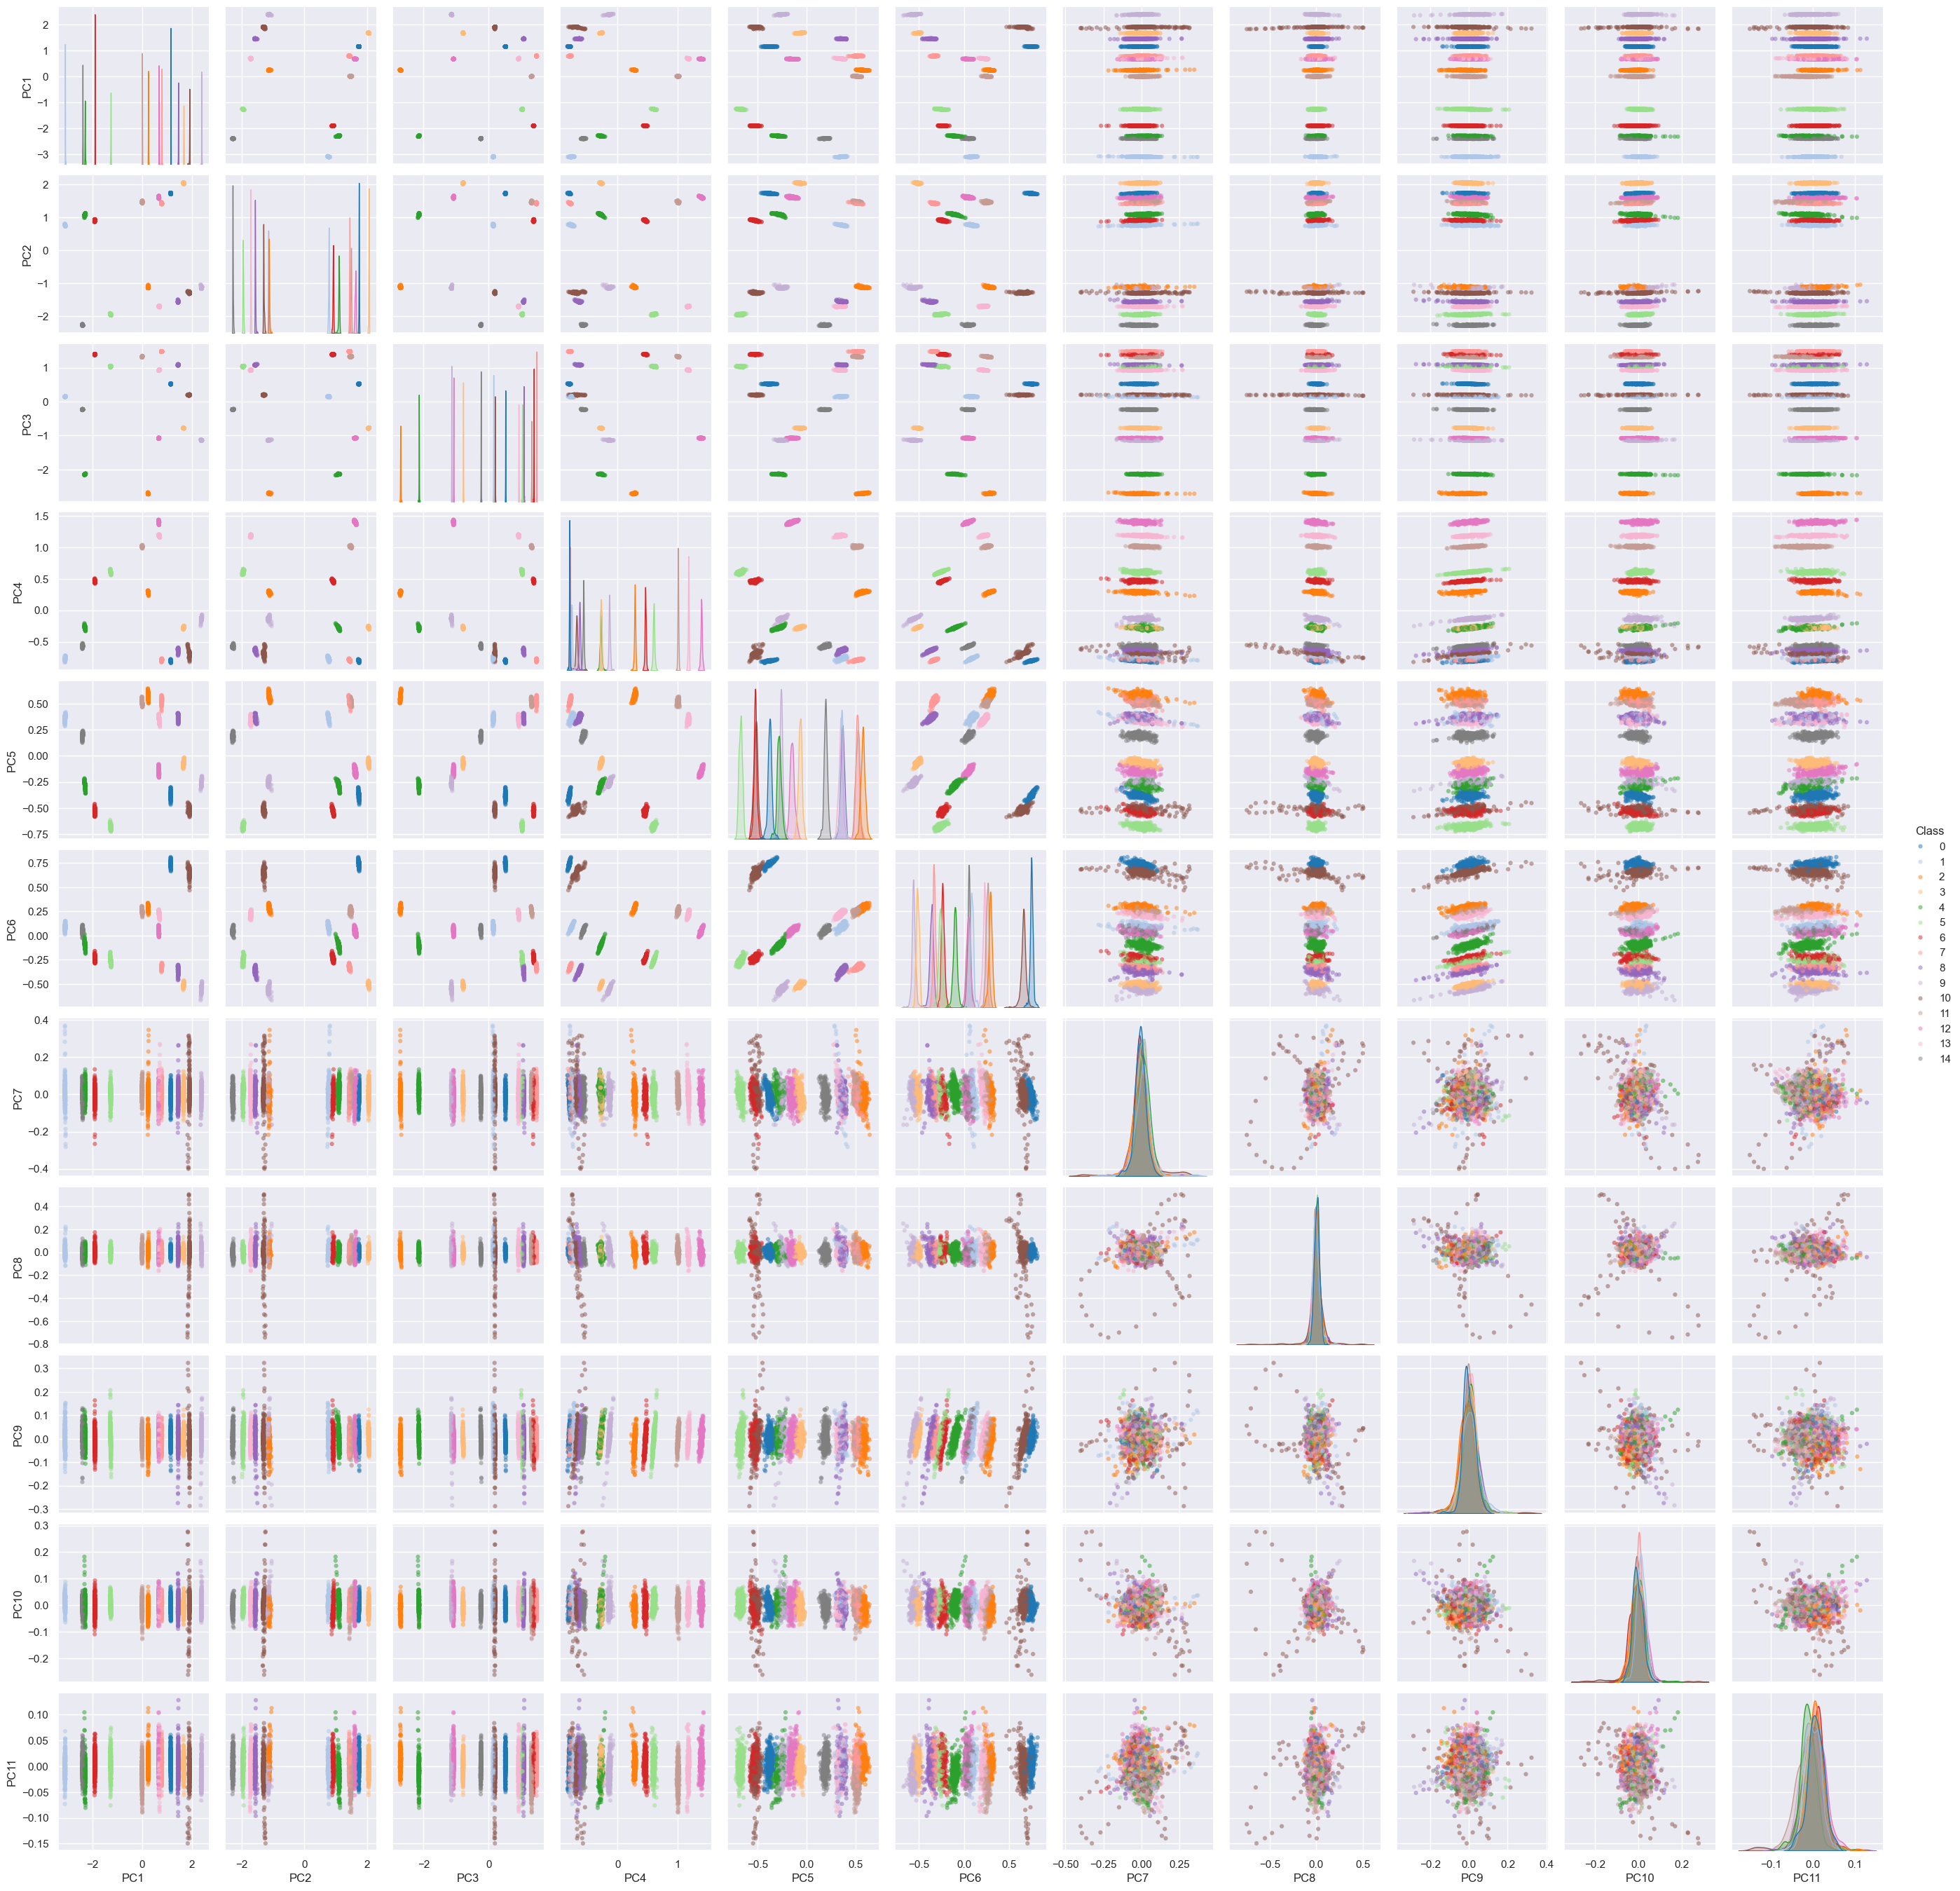

In [78]:
Z, y_h = extract_latents(E, dataloader, device)
Z_flat = Z.mean(dim=1).numpy()  # temporal pooling

pca = PCA(n_components=11)
Z_pca = pca.fit_transform(Z_flat)

columns =[f"PC{i+1}" for i in range(11)]
df = pd.DataFrame(Z_pca, columns=columns)
df["Class"] = y_h

sns.set_theme()
grid = sns.pairplot(df, 
    hue='Class',
    palette='tab20',
    diag_kind='kde',
    plot_kws={"s":20, "alpha": 0.5, "edgecolor":"none"},
    )
plt.show()

In [ ]:
def autocorr_1d(x, max_lag):
    """
    Normalized autocorrelation.
    """
    x = x - np.mean(x)
    var = np.var(x)
    if var == 0:
        return np.zeros(max_lag + 1)

    acf = np.correlate(x, x, mode="full")
    acf = acf[len(acf)//2:]
    acf = acf / (var * np.arange(len(x), 0, -1))

    return acf[:max_lag + 1]

In [ ]:
@torch.no_grad()
def latent_acf(embedder, dataloader, device, max_lag=100):
    embedder.eval()
    acfs = []

    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)
        z, _ = embedder(x,y)

        z_np = z.cpu().numpy()

        # Average across batch and latent dims
        for b in range(z_np.shape[0]):
            for d in range(z_np.shape[2]):
                acfs.append(
                    autocorr_1d(z_np[b, :, d], max_lag)
                )

    return np.mean(acfs, axis=0)

In [ ]:
@torch.no_grad()
def reconstructed_eeg_acf(embedder, recovery, dataloader, device, max_lag=100):
    embedder.eval()
    recovery.eval()
    acfs = []

    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)
        z,_ = embedder(x,y)
        x_hat = recovery(z,y)

        x_np = x_hat.cpu().numpy()

        for b in range(x_np.shape[0]):
            for c in range(x_np.shape[2]):
                acfs.append(
                    autocorr_1d(x_np[b, :, c], max_lag)
                )

    return np.mean(acfs, axis=0)


In [ ]:
def raw_eeg_acf(dataloader, max_lag=100):
    acfs = []
    for x, y in dataloader:
        x_np = x.numpy()
        for b in range(x_np.shape[0]):
            for c in range(x_np.shape[2]):
                acfs.append(
                    autocorr_1d(x_np[b, :, c], max_lag)
                )
    return np.mean(acfs, axis=0)


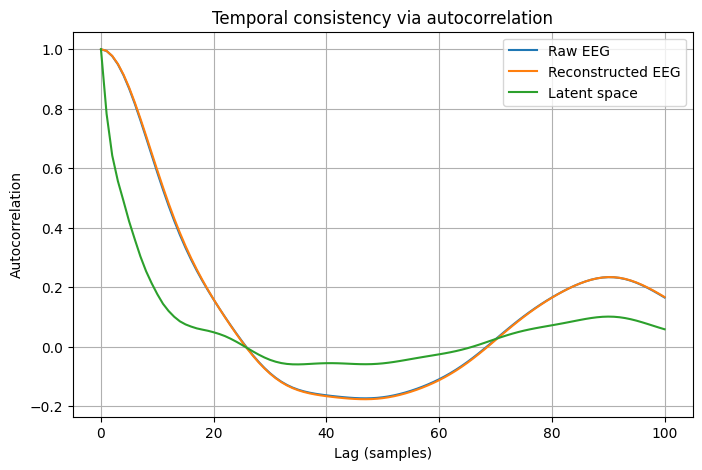

In [ ]:
max_lag = 100

acf_latent = latent_acf(E, dataloader, device, max_lag)
acf_recon  = reconstructed_eeg_acf(E, R, dataloader, device, max_lag)
acf_raw    = raw_eeg_acf(dataloader, max_lag)

plt.figure(figsize=(8, 5))
plt.plot(acf_raw, label="Raw EEG")
plt.plot(acf_recon, label="Reconstructed EEG")
plt.plot(acf_latent, label="Latent space")

plt.xlabel("Lag (samples)")
plt.ylabel("Autocorrelation")
plt.legend()
plt.title("Temporal consistency via autocorrelation")
plt.grid(True)
plt.show()


In [ ]:
def latent_classification_score(H, labels):
    """
    Train a simple classifier on latent vectors.

    Args:
        H: latent embeddings [N, T, H]
        labels: class labels [N]

    Returns:
        classification accuracy
    """

    # Temporal pooling
    H_flat = torch.cat(
        [
            H.mean(dim=1),
            H.std(dim=1),
        ],
        dim=1
    ).numpy()

    labels = labels.numpy()

    X_train, X_test, y_train, y_test = train_test_split(
        H_flat,
        labels,
        test_size=0.2,
        stratify=labels,
        random_state=42,
    )

    clf = LogisticRegression(
        max_iter=10000,
        solver="lbfgs",
    )

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred, normalize=False)

    return acc

In [ ]:
@torch.no_grad()
def classify(embedder, dataloader, device):
    """
    Evaluate latent separability using logistic regression.

    Args:
        embedder: trained encoder / embedder
        dataloader: yields (x, y)
        device: torch device

    Returns:
        classification accuracy in latent space
    """

    embedder.eval()

    all_h = []
    all_y = []

    for x, y in dataloader:

        x = x.to(device)
        y = y.to(device)

        # Forward pass
        h,_ = embedder(x, y)

        # h shape: [B, T, H]
        all_h.append(h.cpu())
        all_y.append(y.cpu())

    # Concatenate all batches
    H = torch.cat(all_h, dim=0)
    Y = torch.cat(all_y, dim=0)

    score = latent_classification_score(H, Y)

    return score


In [ ]:
classify(E, dataloader, device)

1332.0

In [ ]:
@torch.no_grad()
def reconstruction_stability(embedder, recovery, dataloader, noise_std=0.01):
    embedder.eval()
    recovery.eval()
    recon_score = 0

    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)
        
        z,_ = embedder(x, y)
        x_hat = recovery(z, y)

        x_noisy = x + noise_std * torch.randn_like(x)
        z_noisy, _ = embedder(x_noisy, y)
        x_hat_noisy= recovery(z_noisy, y)
        recon_score += torch.mean((x_hat - x_hat_noisy) ** 2).item()
    
    recon_score /= len(dataloader)

    return recon_score

In [ ]:
reconstruction_stability(E,R, dataloader, noise_std=0.05)

0.0010833922343587048

In [ ]:
def compute_psd(x):
    # x: (N, T)

    X = torch.fft.rfft(x, dim=-1)
    psd = (X.abs() ** 2) / x.shape[-1]

    return psd

In [ ]:
@torch.no_grad()
def latent_psd(embedder, dataloader, device):
    embedder.eval()
    psds = []

    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)

        z, _ = embedder(x, y)  # (B, T, D)

        B, T, D = z.shape

        # reshape so each latent dimension becomes a signal
        z = z.permute(0, 2, 1).reshape(B * D, T)

        psd = compute_psd(z)  # expected shape: (B*D, F)
        

        psds.append(psd)

    psds = torch.cat(psds)

    return psds.mean(dim=0)

In [ ]:
@torch.no_grad()
def real_psd(dataloader, device):
    psds = []

    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)


        B, T, D = x.shape

        # reshape so each latent dimension becomes a signal
        x = x.permute(0, 2, 1).reshape(B * D, T)

        psd = compute_psd(x)  # expected shape: (B*D, F)
        

        psds.append(psd)

    psds = torch.cat(psds)

    return psds.mean(dim=0)

In [ ]:
@torch.no_grad()
def recon_psd(embedder, recovery, dataloader, device):
    embedder.eval()
    recovery.eval()
    psds = []

    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)

        z, _ = embedder(x, y)  # (B, T, D)
        z = recovery(z, y)

        B, T, D = z.shape

        # reshape so each latent dimension becomes a signal
        z = z.permute(0, 2, 1).reshape(B * D, T)

        psd = compute_psd(z)  # expected shape: (B*D, F)
        

        psds.append(psd)

    psds = torch.cat(psds)

    return psds.mean(dim=0)

In [ ]:
latentPSD = latent_psd(E, dataloader, device)
realPSD = real_psd(dataloader, device)
reconPSD = recon_psd(E, R, dataloader, device)

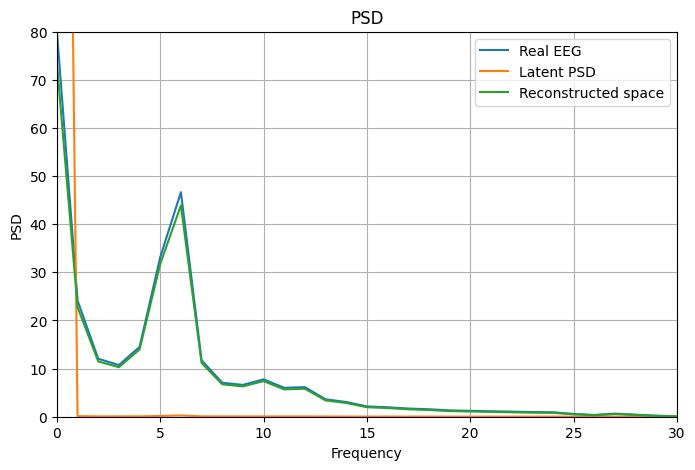

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(realPSD.cpu(), label="Real EEG")
plt.plot(latentPSD.cpu(), label="Latent PSD")
plt.plot(reconPSD.cpu(), label="Reconstructed space")

plt.axis([0, 30, 0, 80])
plt.xlabel("Frequency")
plt.ylabel("PSD")
plt.legend()
plt.title("PSD")
plt.grid(True)
plt.show()
